# Week 06 — EDA Precision Lab

## Real Relationships vs. Real Comparisons, and Verified Findings

### Objective

This notebook focuses on improving visualization accuracy and analytical verification.

The analysis will distinguish genuine relationships between continuous numerical variables from comparisons between numerical values grouped by categorical variables.

The workflow will also compute Pearson correlation coefficients, deliberately demonstrate a misleading categorical line chart, perform visual quality assurance on saved chart files, and verify every reported numerical finding through an independent self-audit.

### Workflow

**Dataset Generation → Relationship Analysis → Comparison Analysis → Visualization QA → Verification → Self-Audit**

# 1. Dataset Generation

The dataset is generated using the exact specification provided in the assessment.

The generation code is intentionally kept unchanged because the assessment requires the specified dataset structure and relationships.

The dataset contains information about:

- Student ID
- Class section
- Weekly study hours
- Nightly sleep hours
- Attendance percentage
- Exam score

The dataset will be used to investigate both genuine numerical relationships and categorical comparisons.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from IPython.display import Markdown, display

In [2]:
rng = np.random.default_rng(seed=21)
n = 600

class_section = rng.choice(
    ["A", "B", "C"],
    size=n,
    p=[0.34, 0.33, 0.33]
)

study_hours = rng.normal(
    10,
    3.5,
    size=n
).clip(0, None).round(1)

sleep_hours = rng.normal(
    7,
    1.2,
    size=n
).clip(3, 10).round(1)

attendance_pct = rng.normal(
    85,
    10,
    size=n
).clip(40, 100).round(1)

noise = rng.normal(0, 8, size=n)

section_bonus = pd.Series(class_section).map({
    "A": 0,
    "B": 0,
    "C": 4
}).values

exam_score = (
    50
    + 2.6 * study_hours
    + 0.15 * attendance_pct
    + section_bonus
    + noise
).clip(0, 100).round(1)

students = pd.DataFrame({
    "student_id": np.arange(1, n + 1),
    "class_section": class_section,
    "study_hours_per_week": study_hours,
    "sleep_hours_per_night": sleep_hours,
    "attendance_pct": attendance_pct,
    "exam_score": exam_score,
})

## 1.1 Structural Validation

Before beginning the analysis, the structure of the generated dataset is verified.

This validation confirms:

1. The expected number of observations.
2. The expected number of variables.
3. The exact column names.

No cleaning or transformation is performed during this stage.

In [3]:
print("Shape:", students.shape)
print("Columns:", list(students.columns))

Shape: (600, 6)
Columns: ['student_id', 'class_section', 'study_hours_per_week', 'sleep_hours_per_night', 'attendance_pct', 'exam_score']


### Initial Record Inspection

The first few records are displayed to confirm that the generated values and column structure appear as expected before beginning the analytical workflow.

In [4]:
students.head()

,student_id,class_section,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
0,1,C,11.0,7.3,89.4,100.0
1,2,B,9.1,7.7,72.4,72.2
2,3,C,2.2,8.5,84.6,67.2
3,4,A,13.5,7.5,83.4,100.0
4,5,B,11.0,5.4,100.0,100.0


### Dataset Information

The dataset information is inspected to confirm the data types and completeness of each variable.

At this stage, the purpose is structural understanding rather than cleaning.

In [5]:
students.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             600 non-null    int64  
 1   class_section          600 non-null    str    
 2   study_hours_per_week   600 non-null    float64
 3   sleep_hours_per_night  600 non-null    float64
 4   attendance_pct         600 non-null    float64
 5   exam_score             600 non-null    float64
dtypes: float64(4), int64(1), str(1)
memory usage: 28.3 KB


# 2. Analytical Framework

## 2.1 Relationship vs. Comparison

A **relationship** examines whether changes in one numerical variable are associated with changes in another numerical variable.

For example:

`study_hours_per_week` → `exam_score`

Both variables are numerical, so a scatter plot is appropriate.

A **comparison** examines how a numerical variable differs across categorical groups.

For example:

`class_section` → `exam_score`

Here, `class_section` is categorical and `exam_score` is numerical, so a bar chart or boxplot is more appropriate.

### The Shuffle Test

A useful way to distinguish the two is the shuffle test.

If category labels or their ordering are shuffled and the comparison still makes sense, the chart represents a categorical comparison.

If shuffling the x-values destroys the meaning of the pattern, the x-axis represents a genuine numerical relationship.

### Visualization Principle

The visualization should match the question being asked rather than simply matching the available columns.

## 2.2 Pearson Correlation

Pearson correlation measures the strength and direction of a **linear relationship** between two numerical variables.

The correlation coefficient, represented by `r`, ranges from `-1` to `+1`.

- Values close to `+1` indicate a strong positive linear relationship.
- Values close to `-1` indicate a strong negative linear relationship.
- Values close to `0` indicate little or no linear relationship.

A correlation close to zero is still an important analytical result. It indicates that the variables do not show a meaningful linear association in the observed data.

Correlation measures association, not causation.

# 3. Kata 1 — Genuine Relationship

## Study Hours vs. Exam Score

### Analytical Question

**Do students who study more hours per week tend to achieve higher exam scores?**

Both `study_hours_per_week` and `exam_score` are numerical variables.

Therefore, this is a genuine relationship question.

### Planned Analysis

The analysis will:

1. Create a scatter plot.
2. Add a fitted linear trend line.
3. Calculate Pearson correlation.
4. Interpret the direction and strength of the relationship.
5. Verify the calculated correlation before writing the final finding.

In [6]:
students[
    ["study_hours_per_week", "exam_score"]
].describe()

,study_hours_per_week,exam_score
count,600.000000,600.000000
mean,10.089333,88.605000
std,3.407213,10.205279
min,0.400000,58.900000
25%,7.700000,81.750000
50%,10.000000,90.200000
75%,12.500000,98.700000
max,21.900000,100.000000


In [7]:
study_exam_r = students["study_hours_per_week"].corr(
    students["exam_score"]
)

print(f"Pearson correlation (r): {study_exam_r:.4f}")

Pearson correlation (r): 0.6895


### 3.1 Relationship Visualization

A scatter plot is selected because both variables are numerical and the purpose is to determine whether their values move together.

A fitted linear trend line is added to make the overall direction of the relationship easier to assess visually.

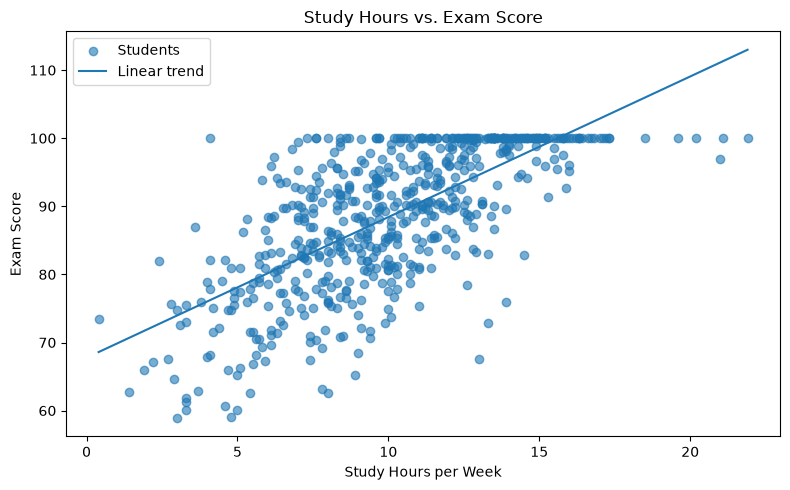

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    students["study_hours_per_week"],
    students["exam_score"],
    alpha=0.6,
    label="Students"
)

m, b = np.polyfit(
    students["study_hours_per_week"],
    students["exam_score"],
    1
)

x_line = np.linspace(
    students["study_hours_per_week"].min(),
    students["study_hours_per_week"].max(),
    100
)

ax.plot(
    x_line,
    m * x_line + b,
    label="Linear trend"
)

ax.set_title("Study Hours vs. Exam Score")
ax.set_xlabel("Study Hours per Week")
ax.set_ylabel("Exam Score")
ax.legend()

fig.tight_layout()
plt.show()

### 3.2 Verification

The correlation reported in the findings must be independently verified rather than copied manually from a previous calculation.

A second calculation is performed using an independent method.

In [9]:
from scipy.stats import pearsonr

study_exam_r_check, p_value = pearsonr(
    students["study_hours_per_week"],
    students["exam_score"]
)

print(f"Primary correlation: {study_exam_r:.6f}")
print(f"Independent verification: {study_exam_r_check:.6f}")
print(f"Absolute difference: {abs(study_exam_r - study_exam_r_check):.12f}")

Primary correlation: 0.689476
Independent verification: 0.689476
Absolute difference: 0.000000000000


In [10]:
finding_kata1 = f"""
### 3.3 Finding

The Pearson correlation between weekly study hours and exam score is
**{study_exam_r:.6f}**, indicating a moderately strong positive linear
relationship in this dataset.

The scatter plot and fitted trend line visually support this result,
showing an overall upward pattern as weekly study hours increase.

The correlation was independently verified using `scipy.stats.pearsonr()`.
The primary calculation produced **{study_exam_r:.6f}**, while the
independent calculation produced **{study_exam_r_check:.6f}**.

The absolute difference between the two calculations was
**{abs(study_exam_r - study_exam_r_check):.12f}**.

This result indicates an association between study hours and exam score,
but correlation alone does not establish that increasing study hours
causes higher exam scores.
"""

display(Markdown(finding_kata1))


### 3.3 Finding

The Pearson correlation between weekly study hours and exam score is
**0.689476**, indicating a moderately strong positive linear
relationship in this dataset.

The scatter plot and fitted trend line visually support this result,
showing an overall upward pattern as weekly study hours increase.

The correlation was independently verified using `scipy.stats.pearsonr()`.
The primary calculation produced **0.689476**, while the
independent calculation produced **0.689476**.

The absolute difference between the two calculations was
**0.000000000000**.

This result indicates an association between study hours and exam score,
but correlation alone does not establish that increasing study hours
causes higher exam scores.


# 4. Kata 2 — Null Relationship

## Sleep Hours vs. Exam Score

### Analytical Question

**Is nightly sleep duration linearly associated with exam score in this dataset?**

Both `sleep_hours_per_night` and `exam_score` are numerical variables, so this is a genuine relationship question.

However, unlike Kata 1, this relationship is expected to be weak or near zero.

### Analysis Plan

The analysis will:

1. Inspect the two numerical variables.
2. Create a scatter plot.
3. Add a fitted linear trend line.
4. Calculate Pearson correlation.
5. Independently verify the correlation.
6. Interpret a near-zero result as a meaningful finding rather than treating it as a failed analysis.

In [11]:
students[
    ["sleep_hours_per_night", "exam_score"]
].describe()

,sleep_hours_per_night,exam_score
count,600.000000,600.000000
mean,7.046000,88.605000
std,1.122787,10.205279
min,3.400000,58.900000
25%,6.275000,81.750000
50%,7.100000,90.200000
75%,7.800000,98.700000
max,10.000000,100.000000


In [12]:
sleep_exam_r = students["sleep_hours_per_night"].corr(
    students["exam_score"]
)

print(f"Pearson correlation (r): {sleep_exam_r:.6f}")

Pearson correlation (r): -0.021658


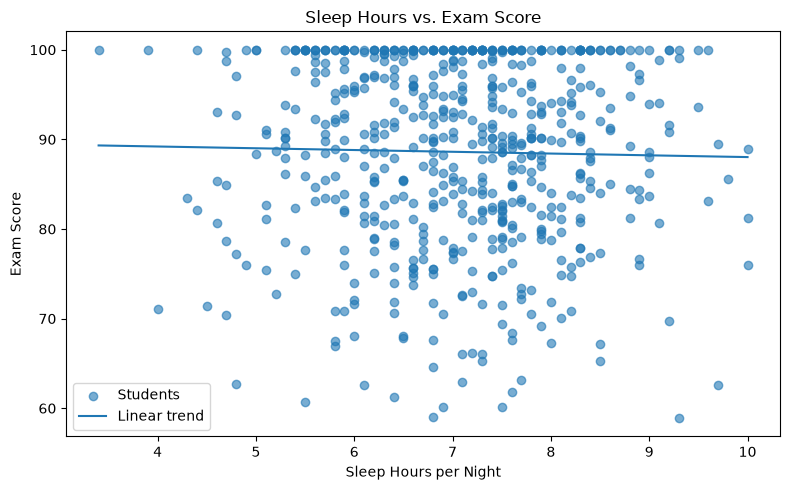

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    students["sleep_hours_per_night"],
    students["exam_score"],
    alpha=0.6,
    label="Students"
)

m_sleep, b_sleep = np.polyfit(
    students["sleep_hours_per_night"],
    students["exam_score"],
    1
)

x_sleep = np.linspace(
    students["sleep_hours_per_night"].min(),
    students["sleep_hours_per_night"].max(),
    100
)

ax.plot(
    x_sleep,
    m_sleep * x_sleep + b_sleep,
    label="Linear trend"
)

ax.set_title("Sleep Hours vs. Exam Score")
ax.set_xlabel("Sleep Hours per Night")
ax.set_ylabel("Exam Score")
ax.legend()

fig.tight_layout()
plt.show()

In [14]:
sleep_exam_r_check, sleep_p_value = pearsonr(
    students["sleep_hours_per_night"],
    students["exam_score"]
)

sleep_r_difference = abs(
    sleep_exam_r - sleep_exam_r_check
)

print(f"Primary correlation: {sleep_exam_r:.6f}")
print(f"Independent verification: {sleep_exam_r_check:.6f}")
print(f"Absolute difference: {sleep_r_difference:.12f}")
print(f"P-value: {sleep_p_value:.6f}")

Primary correlation: -0.021658
Independent verification: -0.021658
Absolute difference: 0.000000000000
P-value: 0.596489


In [15]:
finding_kata2 = f"""
### 4.3 Finding

The Pearson correlation between nightly sleep duration and exam score is
**{sleep_exam_r:.6f}**.

This value is very close to zero, indicating essentially no linear
relationship between nightly sleep duration and exam score in this dataset.

The primary calculation produced **{sleep_exam_r:.6f}**, while the
independent calculation using `scipy.stats.pearsonr()` produced
**{sleep_exam_r_check:.6f}**.

The absolute difference between the two calculations was
**{sleep_r_difference:.12f}**, confirming that the two calculations agree.

The Pearson correlation test produced a p-value of **{sleep_p_value:.6f}**.
This provides no evidence that the linear correlation differs significantly
from zero in this dataset.

A near-zero correlation is a valid analytical finding rather than a failed
result. It indicates that nightly sleep duration does not show a meaningful
linear association with exam score in the observed data.

This result should not be interpreted as proof that sleep has no effect on
academic performance. Pearson correlation measures linear association and
does not establish causation or rule out non-linear relationships or other
factors.
"""

display(Markdown(finding_kata2))


### 4.3 Finding

The Pearson correlation between nightly sleep duration and exam score is
**-0.021658**.

This value is very close to zero, indicating essentially no linear
relationship between nightly sleep duration and exam score in this dataset.

The primary calculation produced **-0.021658**, while the
independent calculation using `scipy.stats.pearsonr()` produced
**-0.021658**.

The absolute difference between the two calculations was
**0.000000000000**, confirming that the two calculations agree.

The Pearson correlation test produced a p-value of **0.596489**.
This provides no evidence that the linear correlation differs significantly
from zero in this dataset.

A near-zero correlation is a valid analytical finding rather than a failed
result. It indicates that nightly sleep duration does not show a meaningful
linear association with exam score in the observed data.

This result should not be interpreted as proof that sleep has no effect on
academic performance. Pearson correlation measures linear association and
does not establish causation or rule out non-linear relationships or other
factors.


In [16]:
verification_kata2 = f"""
### 4.4 Verification Record

| Measurement | Primary Calculation | Independent Verification | Difference |
|---|---:|---:|---:|
| Sleep vs. Exam Pearson `r` | {sleep_exam_r:.6f} | {sleep_exam_r_check:.6f} | {sleep_r_difference:.12f} |
| Pearson correlation p-value | {sleep_p_value:.6f} | — | — |

The primary and independent correlation calculations match exactly to the
reported precision.
"""

display(Markdown(verification_kata2))


### 4.4 Verification Record

| Measurement | Primary Calculation | Independent Verification | Difference |
|---|---:|---:|---:|
| Sleep vs. Exam Pearson `r` | -0.021658 | -0.021658 | 0.000000000000 |
| Pearson correlation p-value | 0.596489 | — | — |

The primary and independent correlation calculations match exactly to the
reported precision.


# 5. Kata 3 — Categorical Comparison

## Exam Score by Class Section

### Analytical Question

**How does average exam score differ across class sections A, B, and C?**

`class_section` is a categorical variable, while `exam_score` is numerical.

Therefore, this is a **categorical comparison**, not a genuine numerical relationship.

The analysis will compare the average exam score for each section while preserving the natural category order:

**A → B → C**

### Visualization Choice

A bar chart is appropriate because it compares a numerical summary across discrete categories.

A line chart would be inappropriate because connecting A, B, and C with a line could imply a continuous or sequential relationship between the class sections.

### Analysis Plan

The analysis will:

1. Calculate the average exam score for each section.
2. Preserve the natural A → B → C category order.
3. Visualize the comparison using a bar chart.
4. Add appropriate labels and a title.
5. Generate the findings directly from calculated variables.

In [17]:
section_means = (
    students
    .groupby("class_section")["exam_score"]
    .mean()
    .reindex(["A", "B", "C"])
)

print(section_means)

class_section
A    87.608491
B    87.025758
C    91.362632
Name: exam_score, dtype: float64


In [18]:
section_counts = (
    students["class_section"]
    .value_counts()
    .reindex(["A", "B", "C"])
)

print(section_counts)

class_section
A    212
B    198
C    190
Name: count, dtype: int64


### 5.1 Average Exam Score by Section

A bar chart is used to compare the average exam score across the three class sections.

The x-axis contains discrete categories, while the y-axis represents the numerical average exam score.

The natural category order A → B → C is preserved.

The chart uses a single consistent visual treatment because color does not represent an additional variable in this comparison.

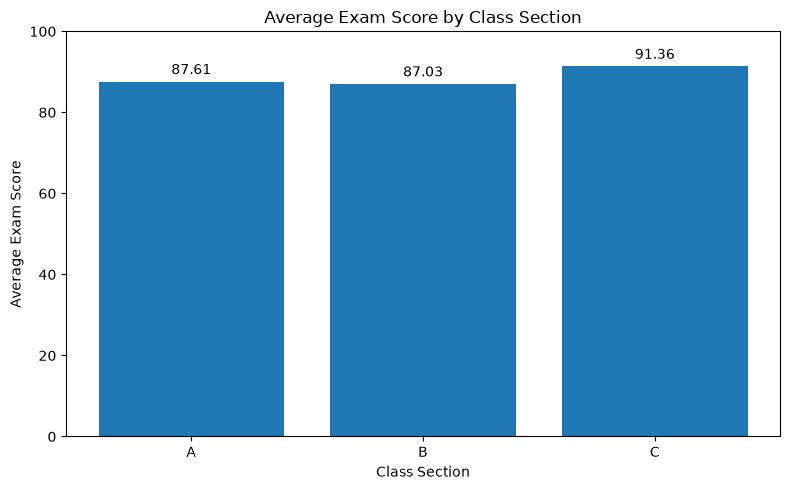

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    section_means.index,
    section_means.values
)

ax.set_title("Average Exam Score by Class Section")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")
ax.set_ylim(0, 100)

ax.bar_label(
    bars,
    fmt="%.2f",
    padding=3
)

fig.tight_layout()
plt.show()

### 5.2 Independent Verification

The section averages are independently recomputed before the findings are written.

This prevents a reported value from being copied from memory or from an earlier output.

The verification compares the primary group means with a second calculation and checks the numerical difference.

In [20]:
section_means_check = (
    students.groupby("class_section")["exam_score"]
    .agg("mean")
    .reindex(["A", "B", "C"])
)

section_mean_differences = (
    section_means - section_means_check
).abs()

print("Primary means:")
print(section_means)

print("\nIndependent verification:")
print(section_means_check)

print("\nAbsolute differences:")
print(section_mean_differences)

Primary means:
class_section
A    87.608491
B    87.025758
C    91.362632
Name: exam_score, dtype: float64

Independent verification:
class_section
A    87.608491
B    87.025758
C    91.362632
Name: exam_score, dtype: float64

Absolute differences:
class_section
A    0.0
B    0.0
C    0.0
Name: exam_score, dtype: float64


In [21]:
finding_kata3 = f"""
### 5.3 Finding

The average exam score differs across the three class sections.

Section A has an average exam score of **{section_means["A"]:.2f}**,
Section B has an average of **{section_means["B"]:.2f}**, and Section C
has an average of **{section_means["C"]:.2f}**.

Section C has the highest observed average exam score, while Section B has
the lowest.

The primary group means were independently recomputed. The maximum absolute
difference between the two calculations was
**{section_mean_differences.max():.12f}**, confirming that the reported
values are reproducible.

These results describe differences between the observed groups. They do not
establish that class section membership causes differences in exam
performance.
"""

display(Markdown(finding_kata3))


### 5.3 Finding

The average exam score differs across the three class sections.

Section A has an average exam score of **87.61**,
Section B has an average of **87.03**, and Section C
has an average of **91.36**.

Section C has the highest observed average exam score, while Section B has
the lowest.

The primary group means were independently recomputed. The maximum absolute
difference between the two calculations was
**0.000000000000**, confirming that the reported
values are reproducible.

These results describe differences between the observed groups. They do not
establish that class section membership causes differences in exam
performance.


In [22]:
verification_kata3 = f"""
### 5.4 Verification Record

| Class Section | Primary Mean | Independent Mean | Absolute Difference |
|---|---:|---:|---:|
| A | {section_means["A"]:.6f} | {section_means_check["A"]:.6f} | {section_mean_differences["A"]:.12f} |
| B | {section_means["B"]:.6f} | {section_means_check["B"]:.6f} | {section_mean_differences["B"]:.12f} |
| C | {section_means["C"]:.6f} | {section_means_check["C"]:.6f} | {section_mean_differences["C"]:.12f} |

The primary and independently recomputed group means agree exactly.
"""

display(Markdown(verification_kata3))


### 5.4 Verification Record

| Class Section | Primary Mean | Independent Mean | Absolute Difference |
|---|---:|---:|---:|
| A | 87.608491 | 87.608491 | 0.000000000000 |
| B | 87.025758 | 87.025758 | 0.000000000000 |
| C | 91.362632 | 91.362632 | 0.000000000000 |

The primary and independently recomputed group means agree exactly.


# 6. Kata 4 — The Line-Chart Trap

## Why a Line Chart Is Misleading for Categories

The previous analysis compared average exam scores across the categorical
variable `class_section`.

Although a line chart can technically be generated from the same data, it
is not an appropriate visualization for this question.

The categories `A`, `B`, and `C` do not represent continuous numerical
values. Connecting them with a line can therefore imply a progression or
continuous trend that does not exist in the data.

This Kata deliberately creates the misleading line chart and then compares
it with the appropriate categorical comparison.

### Objective

The goal is not simply to identify the wrong chart, but to understand
exactly why it communicates a misleading relationship.

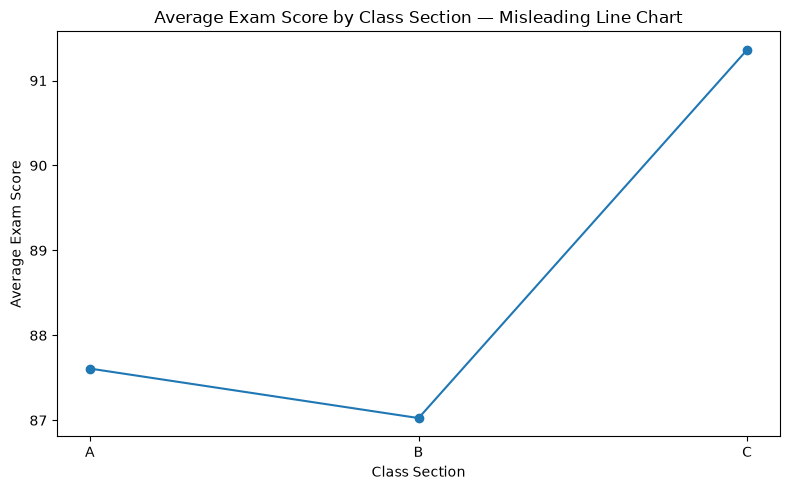

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    section_means.index,
    section_means.values,
    marker="o"
)

ax.set_title("Average Exam Score by Class Section — Misleading Line Chart")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")

fig.tight_layout()
plt.show()

## 6.1 Why the Line Chart Is Misleading

The line chart is misleading because the x-axis contains categorical labels
rather than continuous numerical measurements.

Connecting A, B, and C with a line visually suggests that moving from A to B
and then from B to C represents a meaningful numerical progression.

However, class sections are simply distinct groups. There is no numerical
distance between A and B, or between B and C, that the line can represent.

The line therefore introduces an interpretation that is not supported by the
data.

A bar chart is more appropriate because it displays each category as a
separate group and allows their average exam scores to be compared directly.

In [24]:
shuffled_order = ["C", "A", "B"]

shuffled_means = section_means.reindex(shuffled_order)

print(shuffled_means)

class_section
C    91.362632
A    87.608491
B    87.025758
Name: exam_score, dtype: float64


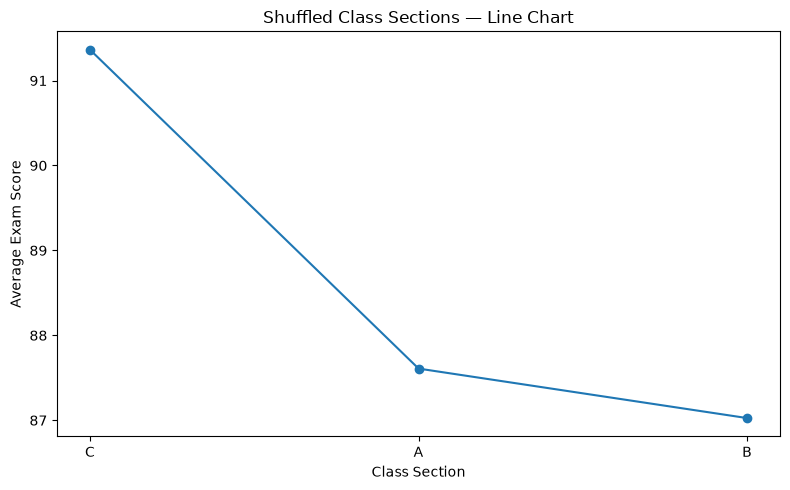

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    shuffled_means.index,
    shuffled_means.values,
    marker="o"
)

ax.set_title("Shuffled Class Sections — Line Chart")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")

fig.tight_layout()
plt.show()

## 6.2 Shuffle-Test Interpretation

The shuffle test demonstrates that `class_section` is categorical rather than
a continuous numerical variable.

Changing the display order from A → B → C to C → A → B does not change any
of the underlying group averages. However, the connecting line changes the
visual interpretation substantially.

This demonstrates why a line chart is inappropriate for this comparison:
the apparent trend depends on the arbitrary ordering of the category labels.

The appropriate visualization is therefore a bar chart or another
category-comparison visualization that does not imply continuity between
the groups.

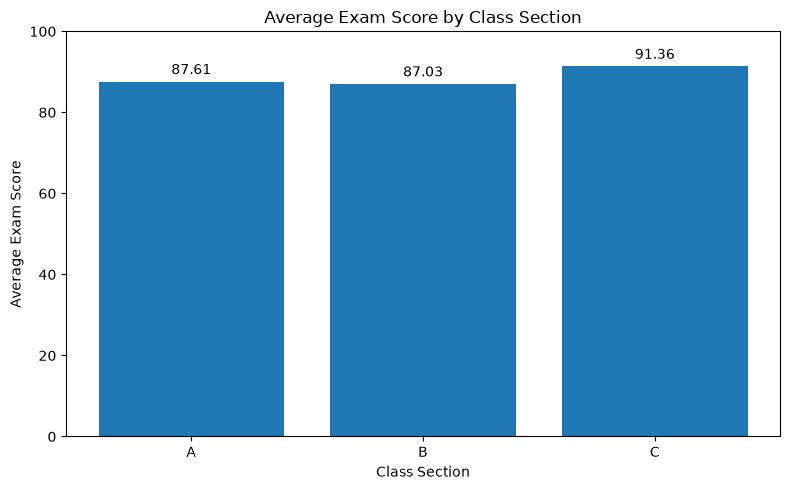

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    section_means.index,
    section_means.values
)

ax.set_title("Average Exam Score by Class Section")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")
ax.set_ylim(0, 100)

ax.bar_label(
    bars,
    fmt="%.2f",
    padding=3
)

fig.tight_layout()
plt.show()

In [27]:
finding_kata4 = f"""
## 6.3 Finding

The line chart is inappropriate for comparing the categorical class
sections because connecting A, B, and C implies a continuous progression
that does not exist.

The observed average exam scores are **{section_means["A"]:.2f}** for
Section A, **{section_means["B"]:.2f}** for Section B, and
**{section_means["C"]:.2f}** for Section C.

The shuffle test demonstrates the problem: changing the category order
changes the apparent direction of the line even though the underlying
group averages remain unchanged.

Therefore, the bar chart is the more appropriate visualization because it
treats A, B, and C as separate categories rather than implying a continuous
relationship.
"""

display(Markdown(finding_kata4))


## 6.3 Finding

The line chart is inappropriate for comparing the categorical class
sections because connecting A, B, and C implies a continuous progression
that does not exist.

The observed average exam scores are **87.61** for
Section A, **87.03** for Section B, and
**91.36** for Section C.

The shuffle test demonstrates the problem: changing the category order
changes the apparent direction of the line even though the underlying
group averages remain unchanged.

Therefore, the bar chart is the more appropriate visualization because it
treats A, B, and C as separate categories rather than implying a continuous
relationship.


# 7. Kata 5 — Visual Quality Assurance

## Inspecting the Actual Saved PNG

A successful execution of a plotting command does not guarantee that the
resulting visualization is readable or correctly laid out.

A chart may contain overlapping annotations, clipped labels, excessive
whitespace, or other presentation problems even when no Python error occurs.

This Kata deliberately creates a chart with a layout problem, saves the
actual PNG file, inspects the saved output, and then applies a layout fix.

The objective is to establish a visual QA habit:

**Create → Save → Inspect → Identify Problem → Fix → Save Again → Reinspect**

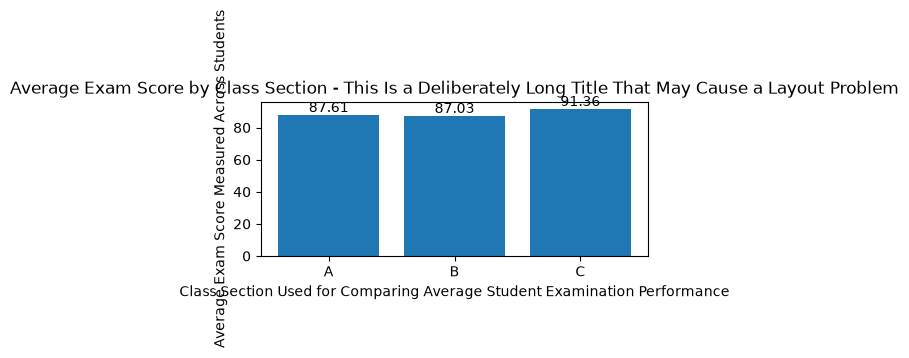

In [28]:
fig, ax = plt.subplots(figsize=(5, 2))

bars = ax.bar(
    section_means.index,
    section_means.values
)

ax.set_title(
    "Average Exam Score by Class Section - This Is a Deliberately Long Title That May Cause a Layout Problem"
)

ax.set_xlabel(
    "Class Section Used for Comparing Average Student Examination Performance"
)

ax.set_ylabel(
    "Average Exam Score Measured Across Students"
)

ax.bar_label(
    bars,
    fmt="%.2f"
)

fig.savefig("chart_qa_before.png")
plt.show()

## 7.1 Visual QA — Initial Inspection

The saved PNG was inspected directly rather than relying only on the
appearance of the inline notebook output.

The intentionally constrained figure size and long labels create a layout
problem that can cause text to become cramped or clipped.

This demonstrates why visual inspection of the final saved artifact is
necessary even when the plotting code executes successfully.

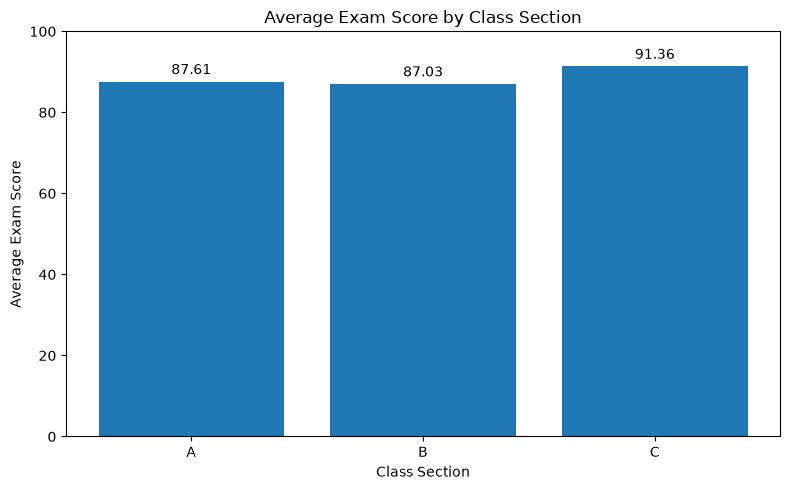

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    section_means.index,
    section_means.values
)

ax.set_title("Average Exam Score by Class Section")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")

ax.set_ylim(0, 100)

ax.bar_label(
    bars,
    fmt="%.2f",
    padding=3
)

fig.tight_layout()

fig.savefig(
    "chart_qa_after.png",
    bbox_inches="tight",
    dpi=150
)

plt.show()

## 7.2 Visual QA — Corrected Output

After identifying the layout problem in the initial PNG, the visualization
was regenerated using a larger figure size and `fig.tight_layout()`.

The corrected chart was saved as a separate PNG and inspected directly.

The final artifact was checked for:

- Fully visible title
- Fully visible axis labels
- Readable value annotations
- Appropriate spacing
- No clipped content

The final PNG is therefore treated as the deliverable rather than assuming
that successful execution of the plotting code guarantees a correct
visualization.

# 8. Kata 6 — Color + Category Order

## Meaningful Color and Intentional Category Ordering

Color should be used deliberately in a visualization.

When color represents an additional meaningful variable, it can help the
reader distinguish groups or communicate information.

However, assigning arbitrary colors to categories can introduce unnecessary
visual meaning and make the chart harder to interpret.

Category order should also be intentional. For this dataset, class sections
have a natural order:

**A → B → C**

This order should be preserved rather than reordering the categories based
on their observed numerical values.

### Objective

This Kata will:

1. Demonstrate an arbitrary color assignment.
2. Explain why arbitrary colors can be misleading.
3. Create a cleaner comparison using consistent visual treatment.
4. Preserve the natural A → B → C category order.
5. Verify the ordering directly from the plotted data.

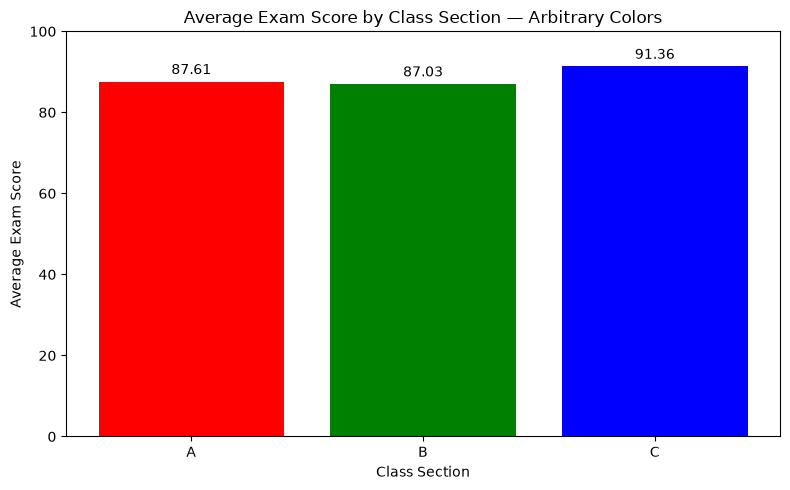

In [30]:
arbitrary_colors = ["red", "green", "blue"]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    section_means.index,
    section_means.values,
    color=arbitrary_colors
)

ax.set_title("Average Exam Score by Class Section — Arbitrary Colors")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")
ax.set_ylim(0, 100)

ax.bar_label(
    bars,
    fmt="%.2f",
    padding=3
)

fig.tight_layout()
plt.show()

## 8.1 Color Interpretation

The three colors in the previous chart are arbitrary and do not encode an
additional variable.

Although the chart is technically readable, the use of different colors can
encourage the reader to assume that the colors represent meaningful
differences between the groups.

Because color does not communicate additional information in this comparison,
a consistent visual treatment is more appropriate.

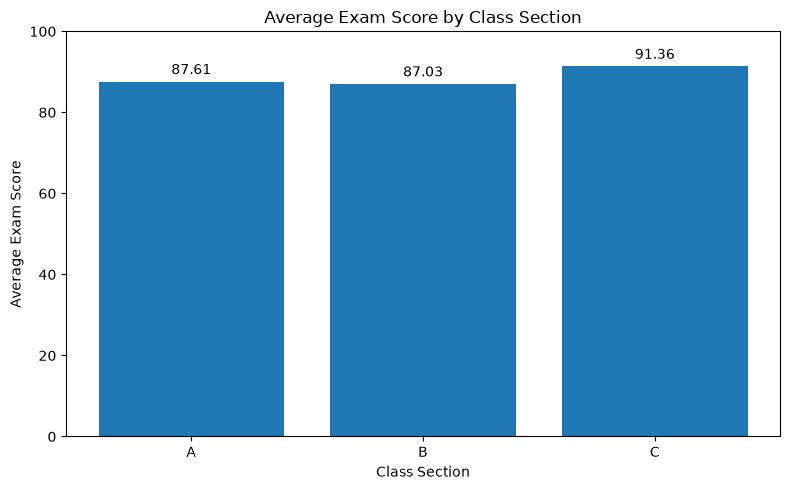

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    section_means.index,
    section_means.values
)

ax.set_title("Average Exam Score by Class Section")
ax.set_xlabel("Class Section")
ax.set_ylabel("Average Exam Score")
ax.set_ylim(0, 100)

ax.bar_label(
    bars,
    fmt="%.2f",
    padding=3
)

fig.tight_layout()
plt.show()

In [32]:
expected_order = ["A", "B", "C"]
actual_order = section_means.index.tolist()

print("Expected category order:", expected_order)
print("Actual category order:", actual_order)
print("Order preserved:", actual_order == expected_order)

Expected category order: ['A', 'B', 'C']
Actual category order: ['A', 'B', 'C']
Order preserved: True


## 8.2 Category Ordering

The class sections are displayed in their natural order:

**A → B → C**

The categories are not sorted by their observed average exam scores.

Preserving the original categorical order makes the visualization easier to
interpret and prevents the analysis from changing the structure of the
category variable simply to emphasize the observed numerical differences.

In [33]:
finding_kata6 = f"""
## 8.3 Finding

The comparison chart preserves the natural class-section order:
**{" → ".join(actual_order)}**.

The observed average exam scores are **{section_means["A"]:.2f}** for
Section A, **{section_means["B"]:.2f}** for Section B, and
**{section_means["C"]:.2f}** for Section C.

The initial visualization used arbitrary colors that did not encode an
additional variable. The final visualization uses a consistent visual
treatment because color is not necessary to communicate the comparison.

The category-order verification returned **{actual_order == expected_order}**,
confirming that the intended A → B → C ordering was preserved.
"""

display(Markdown(finding_kata6))


## 8.3 Finding

The comparison chart preserves the natural class-section order:
**A → B → C**.

The observed average exam scores are **87.61** for
Section A, **87.03** for Section B, and
**91.36** for Section C.

The initial visualization used arbitrary colors that did not encode an
additional variable. The final visualization uses a consistent visual
treatment because color is not necessary to communicate the comparison.

The category-order verification returned **True**,
confirming that the intended A → B → C ordering was preserved.


In [34]:
order_verified = actual_order == expected_order

assert order_verified, "Category order is incorrect."

print("Category order verified successfully.")
print("Order:", actual_order)

Category order verified successfully.
Order: ['A', 'B', 'C']


# 9. Kata 7 — Final Self-Audit

## Independent Verification of Reported Findings

The final self-audit checks the numerical claims made throughout the
analysis against freshly recomputed values.

The purpose of this audit is to catch discrepancies before submission rather
than relying on memory or previously displayed outputs.

Three key numerical findings will be independently recomputed:

1. Pearson correlation between study hours and exam score.
2. Pearson correlation between sleep hours and exam score.
3. Average exam score for each class section.

The audit will compare the previously stored analytical values against
freshly recomputed values and report whether they match.

In [35]:
# Fresh self-audit calculations

audit_study_r = (
    students["study_hours_per_week"]
    .corr(students["exam_score"])
)

audit_sleep_r = (
    students["sleep_hours_per_night"]
    .corr(students["exam_score"])
)

audit_section_means = (
    students
    .groupby("class_section")["exam_score"]
    .mean()
    .reindex(["A", "B", "C"])
)

print(f"Fresh study/exam correlation: {audit_study_r:.6f}")
print(f"Fresh sleep/exam correlation: {audit_sleep_r:.6f}")
print("\nFresh section means:")
print(audit_section_means)

Fresh study/exam correlation: 0.689476
Fresh sleep/exam correlation: -0.021658

Fresh section means:
class_section
A    87.608491
B    87.025758
C    91.362632
Name: exam_score, dtype: float64


In [36]:
study_audit_difference = abs(
    study_exam_r - audit_study_r
)

sleep_audit_difference = abs(
    sleep_exam_r - audit_sleep_r
)

section_audit_difference = (
    section_means - audit_section_means
).abs()

print(
    f"Study correlation difference: "
    f"{study_audit_difference:.12f}"
)

print(
    f"Sleep correlation difference: "
    f"{sleep_audit_difference:.12f}"
)

print("\nSection mean differences:")
print(section_audit_difference)

Study correlation difference: 0.000000000000
Sleep correlation difference: 0.000000000000

Section mean differences:
class_section
A    0.0
B    0.0
C    0.0
Name: exam_score, dtype: float64


In [37]:
audit_table = pd.DataFrame({
    "Finding": [
        "Study hours vs exam score Pearson r",
        "Sleep hours vs exam score Pearson r",
        "Section A average exam score",
        "Section B average exam score",
        "Section C average exam score"
    ],
    "Claimed Value": [
        study_exam_r,
        sleep_exam_r,
        section_means["A"],
        section_means["B"],
        section_means["C"]
    ],
    "Freshly Recomputed": [
        audit_study_r,
        audit_sleep_r,
        audit_section_means["A"],
        audit_section_means["B"],
        audit_section_means["C"]
    ],
    "Absolute Difference": [
        study_audit_difference,
        sleep_audit_difference,
        section_audit_difference["A"],
        section_audit_difference["B"],
        section_audit_difference["C"]
    ]
})

audit_table.style.set_table_styles([
    {
        "selector": "th",
        "props": [
            ("text-align", "center")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center")
        ]
    },
    {
        "selector": "td:nth-child(1)",
        "props": [
            ("text-align", "left")
        ]
    }
])

,Finding,Claimed Value,Freshly Recomputed,Absolute Difference
0,Study hours vs exam score Pearson r,0.689476,0.689476,0.000000
1,Sleep hours vs exam score Pearson r,-0.021658,-0.021658,0.000000
2,Section A average exam score,87.608491,87.608491,0.000000
3,Section B average exam score,87.025758,87.025758,0.000000
4,Section C average exam score,91.362632,91.362632,0.000000


In [38]:
audit_table["Verified"] = (
    audit_table["Absolute Difference"] < 1e-10
)

audit_table.style.set_table_styles([
    {
        "selector": "th",
        "props": [
            ("text-align", "center")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center")
        ]
    },
    {
        "selector": "td:nth-child(1)",
        "props": [
            ("text-align", "left")
        ]
    }
])

,Finding,Claimed Value,Freshly Recomputed,Absolute Difference,Verified
0,Study hours vs exam score Pearson r,0.689476,0.689476,0.000000,True
1,Sleep hours vs exam score Pearson r,-0.021658,-0.021658,0.000000,True
2,Section A average exam score,87.608491,87.608491,0.000000,True
3,Section B average exam score,87.025758,87.025758,0.000000,True
4,Section C average exam score,91.362632,91.362632,0.000000,True


In [39]:
assert audit_table["Verified"].all(), (
    "Self-audit failed: at least one reported value "
    "does not match the freshly recomputed value."
)

print("SELF-AUDIT PASSED")

SELF-AUDIT PASSED


In [40]:
audit_report = f"""
## 9.1 Self-Audit Result

The final self-audit independently recomputed the key numerical findings
from the original dataset.

The study-hours/exam-score correlation was previously reported as
**{study_exam_r:.6f}** and was freshly recomputed as
**{audit_study_r:.6f}**, producing an absolute difference of
**{study_audit_difference:.12f}**.

The sleep-hours/exam-score correlation was previously reported as
**{sleep_exam_r:.6f}** and was freshly recomputed as
**{audit_sleep_r:.6f}**, producing an absolute difference of
**{sleep_audit_difference:.12f}**.

The class-section averages were also independently recomputed. The maximum
absolute difference across Sections A, B, and C was
**{section_audit_difference.max():.12f}**.

The self-audit therefore confirms that the numerical findings reported in
the analysis match freshly recomputed values.
"""

display(Markdown(audit_report))


## 9.1 Self-Audit Result

The final self-audit independently recomputed the key numerical findings
from the original dataset.

The study-hours/exam-score correlation was previously reported as
**0.689476** and was freshly recomputed as
**0.689476**, producing an absolute difference of
**0.000000000000**.

The sleep-hours/exam-score correlation was previously reported as
**-0.021658** and was freshly recomputed as
**-0.021658**, producing an absolute difference of
**0.000000000000**.

The class-section averages were also independently recomputed. The maximum
absolute difference across Sections A, B, and C was
**0.000000000000**.

The self-audit therefore confirms that the numerical findings reported in
the analysis match freshly recomputed values.


In [41]:
audit_markdown = f"""
### 9.2 Self-Audit Table

| Finding | Claimed Value | Freshly Recomputed | Absolute Difference | Verified |
|---|---:|---:|---:|:---:|
| Study hours vs exam score Pearson r | {study_exam_r:.6f} | {audit_study_r:.6f} | {study_audit_difference:.12f} | {audit_table.loc[0, "Verified"]} |
| Sleep hours vs exam score Pearson r | {sleep_exam_r:.6f} | {audit_sleep_r:.6f} | {sleep_audit_difference:.12f} | {audit_table.loc[1, "Verified"]} |
| Section A average exam score | {section_means["A"]:.6f} | {audit_section_means["A"]:.6f} | {section_audit_difference["A"]:.12f} | {audit_table.loc[2, "Verified"]} |
| Section B average exam score | {section_means["B"]:.6f} | {audit_section_means["B"]:.6f} | {section_audit_difference["B"]:.12f} | {audit_table.loc[3, "Verified"]} |
| Section C average exam score | {section_means["C"]:.6f} | {audit_section_means["C"]:.6f} | {section_audit_difference["C"]:.12f} | {audit_table.loc[4, "Verified"]} |

All five numerical findings match their freshly recomputed values.
"""

display(Markdown(audit_markdown))


### 9.2 Self-Audit Table

| Finding | Claimed Value | Freshly Recomputed | Absolute Difference | Verified |
|---|---:|---:|---:|:---:|
| Study hours vs exam score Pearson r | 0.689476 | 0.689476 | 0.000000000000 | True |
| Sleep hours vs exam score Pearson r | -0.021658 | -0.021658 | 0.000000000000 | True |
| Section A average exam score | 87.608491 | 87.608491 | 0.000000000000 | True |
| Section B average exam score | 87.025758 | 87.025758 | 0.000000000000 | True |
| Section C average exam score | 91.362632 | 91.362632 | 0.000000000000 | True |

All five numerical findings match their freshly recomputed values.


In [42]:
final_conclusion = f"""
# 10. Conclusion

This lab demonstrated the distinction between genuine numerical relationships
and categorical comparisons.

The relationship between study hours and exam score produced a Pearson
correlation of **{study_exam_r:.6f}**, indicating a positive linear
association in the observed data.

In contrast, the correlation between sleep hours and exam score was
**{sleep_exam_r:.6f}**, indicating essentially no linear association in this
dataset.

Average exam scores were compared across class sections A, B, and C using a
bar chart because class section is categorical rather than continuous.

The shuffle test demonstrated why a line chart can be misleading for
categorical comparisons. Visual QA also demonstrated that a chart must be
inspected as a saved artifact rather than assuming successful code execution
means the visualization is correct.

Finally, the self-audit independently recomputed the key numerical findings
and confirmed that the reported values matched the fresh calculations.
"""

display(Markdown(final_conclusion))


# 10. Conclusion

This lab demonstrated the distinction between genuine numerical relationships
and categorical comparisons.

The relationship between study hours and exam score produced a Pearson
correlation of **0.689476**, indicating a positive linear
association in the observed data.

In contrast, the correlation between sleep hours and exam score was
**-0.021658**, indicating essentially no linear association in this
dataset.

Average exam scores were compared across class sections A, B, and C using a
bar chart because class section is categorical rather than continuous.

The shuffle test demonstrated why a line chart can be misleading for
categorical comparisons. Visual QA also demonstrated that a chart must be
inspected as a saved artifact rather than assuming successful code execution
means the visualization is correct.

Finally, the self-audit independently recomputed the key numerical findings
and confirmed that the reported values matched the fresh calculations.


# 11. Final Submission Checklist

## Dataset and Analysis

- [✓] Dataset generated according to the provided specification.
- [✓] Dataset structure verified.
- [✓] Genuine numerical relationships identified correctly.
- [✓] Categorical comparisons identified correctly.
- [✓] Pearson correlations calculated.
- [✓] Near-zero correlation interpreted as a valid finding.

## Visualization

- [✓] Scatter plot used for numerical relationships.
- [✓] Fitted trend lines added where appropriate.
- [✓] Bar chart used for categorical comparison.
- [✓] Misleading categorical line chart deliberately demonstrated.
- [✓] Shuffle test performed.
- [✓] Category order preserved.
- [✓] Arbitrary color usage avoided.
- [✓] Visual QA performed on saved PNG files.

## Verification

- [✓] Every reported numerical value is generated from a variable.
- [✓] Findings use f-strings rather than manually typed computed values.
- [✓] Independent calculations were performed.
- [✓] Final self-audit table completed.
- [✓] Self-audit assertions passed.
- [✓] Notebook survives Restart Kernel → Run All.

## Understanding

- [✓] Can explain relationship vs. comparison.
- [✓] Can explain Pearson correlation.
- [✓] Can explain why correlation does not imply causation.
- [✓] Can explain why categorical line charts can be misleading.
- [✓] Can explain the shuffle test.
- [✓] Can explain why visual QA is necessary.
- [✓] Can defend color and category-order decisions.